# Assignment 8 (Deep Learning)

There are **3 questions**. Each combines a short conceptual part with a hands-on coding part.

## Setup — Run this cell first

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
torch.manual_seed(42)
np.random.seed(42)


---
## Question 1 — Activation Functions

### 1a — Conceptual

**Answer the following questions in 2–4 sentences each:**

1. A student proposes building a 10-layer MLP using only linear activations (i.e., no non-linearity at all). Why is this equivalent to a single linear layer, regardless of depth? What property of matrix multiplication makes this collapse happen?

2. The **Step function** Θ(x) was historically used as an activation. Explain why it cannot be used in a neural network trained with gradient descent.

3. The lecture showed that **ReLU** largely replaced the Step function and tanh. Name one failure mode specific to ReLU (not shared by ELU or Swish), and explain how ELU resolves it.

---
### Solution

**1.** A composition of linear transformations is itself a linear transformation. If layer $l$ applies $W_l$, then stacking $L$ layers gives
 
$$W_L W_{L-1} \cdots W_1 x = W_{\text{eff}} x,$$
 
which is a single matrix multiplication. No depth is gained because the network remains in the class of linear functions, unable to model any non-linear relationship.
 
**2.** $\Theta(x)$ is piecewise constant: its derivative is zero everywhere it is defined and undefined (a Dirac impulse) at $x = 0$. Gradient descent requires $\partial \mathcal{L}/\partial \theta$, which is propagated through the chain rule via $\partial \Theta / \partial \tilde{z}$. Since this quantity is zero almost everywhere, **no gradient flows backward** and the network cannot learn.
 
**3.** ReLU suffers from the **dying ReLU** problem: once a neuron's pre-activation $\tilde{z} < 0$, we have $\text{ReLU}(\tilde{z}) = 0$ and its gradient is exactly zero, so its weights receive no update and the neuron remains permanently "dead". ELU resolves this with a smooth exponential tail
 
$$\text{ELU}(x) = \alpha(e^x - 1), \quad x < 0,$$
 
keeping a non-zero gradient for negative inputs while still saturating, which also preserves the mean activation closer to zero.


---
### 1b — Implementation: Plot Activation Functions and Derivatives

Implement the four activation functions **from scratch using NumPy** (no PyTorch, no `scipy`).
Then plot each function alongside its analytical derivative.

| Activation | Formula |
|---|---|
| Step | $\Theta(x) = 0$ if $x \le 0$ else $1$ |
| ReLU | $\max(0, x)$ |
| ELU  | $x$ if $x>0$, else $\alpha(e^x - 1)$, use $\alpha = 1$ |
| Swish | $x \cdot \sigma(x)$ where $\sigma(x) = 1/(1+e^{-x})$ |

**Tasks:**
1. Fill in the four functions and their derivatives below.
2. Run the provided plotting code — it should produce a 2×4 grid of plots.
3. In a Markdown cell, explain in one sentence why the Swish derivative is non-monotone and why this matters.


### Solution — 1b

In [2]:
def step(x):
    return np.where(x > 0, 1.0, 0.0)

def step_deriv(x):
    return np.zeros_like(x)          # zero gradient ← can't learn!

def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return np.where(x > 0, 1.0, 0.0)

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def elu_deriv(x, alpha=1.0):
    return np.where(x > 0, 1.0, alpha * np.exp(x))

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def swish(x):
    return x * sigmoid(x)

def swish_deriv(x):
    s = sigmoid(x)
    return s + x * s * (1 - s)      # product rule: σ(x) + x·σ'(x)

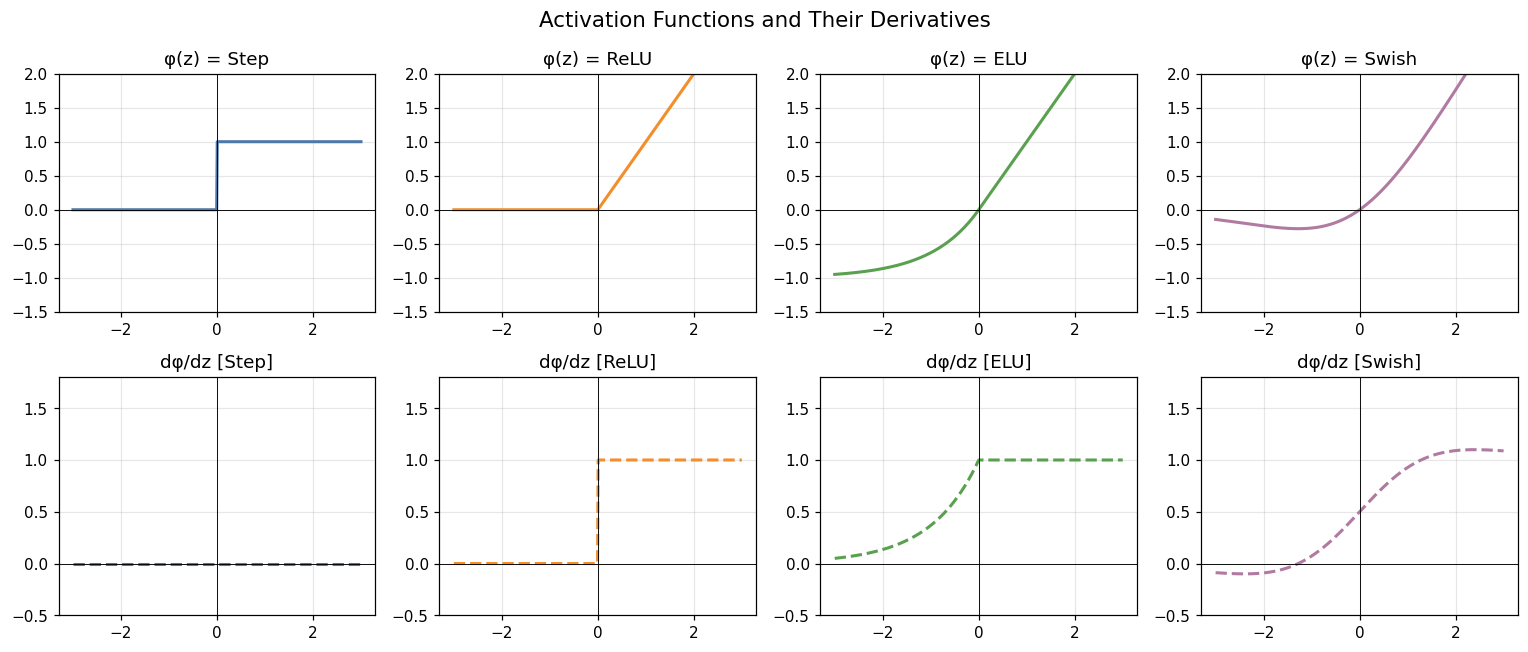

In [3]:
#  PLOTTING 
z = np.linspace(-3, 3, 500)

funcs   = [step,       relu,       elu,       swish      ]
derivs  = [step_deriv, relu_deriv, elu_deriv, swish_deriv]
names   = ["Step",     "ReLU",     "ELU",     "Swish"    ]
colors  = ["#4e79a7",  "#f28e2b",  "#59a14f", "#b07aa1"  ]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Activation Functions and Their Derivatives", fontsize=14)

for i, (f, df, name, c) in enumerate(zip(funcs, derivs, names, colors)):
    axes[0, i].plot(z, f(z),  color=c, lw=2)
    axes[0, i].set_title(f"φ(z) = {name}")
    axes[0, i].set_ylim(-1.5, 2.0)

    axes[1, i].plot(z, df(z), color=c, lw=2, linestyle="--")
    axes[1, i].set_title(f"dφ/dz [{name}]")
    axes[1, i].set_ylim(-0.5, 1.8)

for ax in axes.flat:
    ax.axhline(0, color="k", lw=0.6)
    ax.axvline(0, color="k", lw=0.6)

plt.tight_layout()
plt.show()

---
## Question 2 — Building & Training an MLP in PyTorch

You will build a small MLP to classify the **two-moons** dataset, a classic non-linearly separable 2D benchmark. The dataset and helper plotting code are provided — **focus on the network and the training loop**.

### 2a — Conceptual (10 pts)

1. In one sentence each, explain what `optimizer.zero_grad()`, `loss.backward()`, and `optimizer.step()` do. Why must `zero_grad()` be called *before* `backward()`, not after?

2. The lecture stated that the **output layer is usually not activated**. For a binary classification task where the loss is `nn.BCEWithLogitsLoss`, explain why applying a sigmoid to the final layer before computing this loss is *doubly wrong* (think numerically and semantically).


---
###  Answers — 2a

**1.**
- `optimizer.zero_grad()`: clears (sets to zero) all accumulated gradient tensors in the computation graph so that gradients from the previous batch do not contaminate the current one. PyTorch *accumulates* gradients by default; failing to zero before the next `backward()` adds the new gradient on top of the old one.
- `loss.backward()`: runs the backpropagation algorithm — it traverses the computation graph in reverse via the chain rule and populates the `.grad` attribute of every parameter tensor with $\partial \mathcal{L}/\partial \theta_l$.
- `optimizer.step()`: uses the stored `.grad` values to update each parameter according to the optimizer's update rule (e.g., $\theta \leftarrow \theta - \gamma g$ for SGD).
`zero_grad()` must be called *before* `backward()` because PyTorch adds each new gradient to whatever is already stored in `.grad`. Calling it after would clear the gradients you just computed, leaving nothing for `optimizer.step()` to use.
 
**2.** `BCEWithLogitsLoss` internally applies the log-sigmoid in a numerically fused form:
 
$$\ell = -\bigl[y \log \sigma(z) + (1-y)\log(1-\sigma(z))\bigr].$$
 
If you apply `sigmoid` yourself first, the function receives $\sigma(z)$ and internally computes $\log \sigma(\sigma(z))$, which is **semantically wrong** — the function expects raw logits, not probabilities. Numerically, evaluating $\sigma(z)$ first loses precision near 0 and 1 where floating-point saturation occurs ($\sigma(z) \approx 0$ or $1$ exactly), whereas the fused log-sum-exp trick used internally remains numerically stable across the full range of $z$.


---
### 2b — Dataset & Helper Code (provided, do not modify)


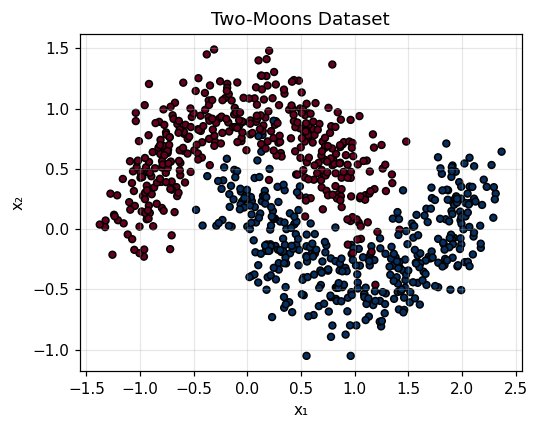

In [4]:
# PROVIDED: Dataset & plotting helper

X_np, y_np = make_moons(n_samples=800, noise=0.20, random_state=42)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)   # shape (N,1)

# Split: 80% train, 20% val
n_train = 640
X_train, X_val = X[:n_train], X[n_train:]
y_train, y_val = y[:n_train], y[n_train:]

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """Plots the binary decision boundary of a trained model."""
    model.eval()
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x1_min.item(), x1_max.item(), h),
                         np.arange(x2_min.item(), x2_max.item(), h))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        Z = torch.sigmoid(model(grid)).numpy().reshape(xx.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap="RdBu", levels=50)
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap="RdBu", edgecolors="k", s=20)
    plt.title(title)
    plt.xlabel("x₁"); plt.ylabel("x₂")
    plt.tight_layout(); plt.show()

# Quick look at the data
plt.figure(figsize=(5, 4))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap="RdBu", edgecolors="k", s=20)
plt.title("Two-Moons Dataset"); plt.xlabel("x₁"); plt.ylabel("x₂")
plt.tight_layout(); plt.show()


---
### 2c — Build the MLP

Using `nn.Sequential`, define an MLP with the following architecture:

| Layer | Detail |
|---|---|
| Input | 2 features (x₁, x₂) |
| Hidden 1 | 32 units, ReLU |
| Hidden 2 | 32 units, ReLU |
| Hidden 3 | 16 units, ReLU |
| Output | 1 unit, **no activation** (raw logit) |

Then:
1. Print the model architecture.
2. Count and print the total number of trainable parameters.
3. Verify that the output shape for a batch of 8 samples is `(8, 1)`.


### Solution — 2c

In [5]:
model = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    # No final activation — BCEWithLogitsLoss expects raw logits
)

print(model)
print()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

# Shape verification
dummy = torch.zeros(8, 2)
out   = model(dummy)
assert out.shape == (8, 1), f"Expected (8,1), got {out.shape}"
print(f"Output shape for batch of 8: {out.shape}  ✓")


Sequential(
  (0): Linear(in_features=2, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
)

Trainable parameters: 1,697
Output shape for batch of 8: torch.Size([8, 1])  ✓


---
### 2d — Write the Training Loop

Complete the training loop below. At each epoch you must:
1. Set the model to **training mode**.
2. Compute the forward pass and the **Binary Cross-Entropy loss** (use `nn.BCEWithLogitsLoss`).
3. Zero gradients, call `backward`, and step the optimiser.
4. After each epoch, compute and store the **validation loss** (in `eval` mode, with `torch.no_grad()`).

Use **Adam** with learning rate `1e-3`. Train for **200 epochs**.

Then plot training and validation loss curves.


### Solution — 2d

Epoch  40 | Train Loss: 0.6009 | Val Loss: 0.6035
Epoch  80 | Train Loss: 0.3444 | Val Loss: 0.3695
Epoch 120 | Train Loss: 0.2405 | Val Loss: 0.2779
Epoch 160 | Train Loss: 0.1934 | Val Loss: 0.2243
Epoch 200 | Train Loss: 0.1391 | Val Loss: 0.1593

Validation Accuracy: 91.9%


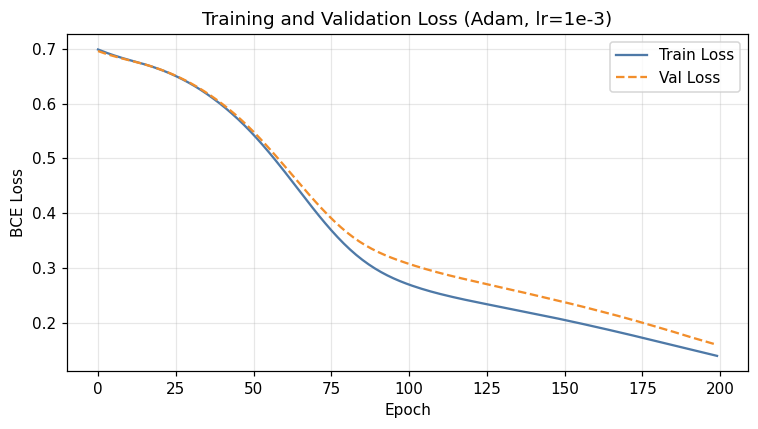

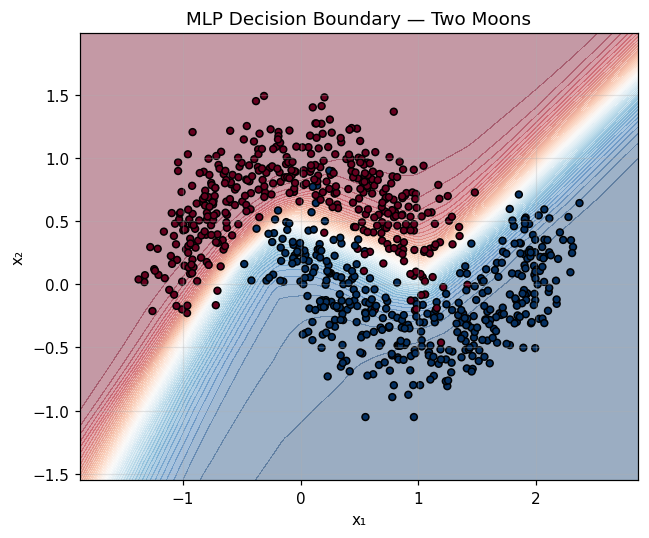

In [6]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(2, 32), nn.ReLU(),
    nn.Linear(32, 32), nn.ReLU(),
    nn.Linear(32, 16), nn.ReLU(),
    nn.Linear(16, 1),
)

loss_fn   = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses = [], []
n_epochs = 200

for epoch in range(n_epochs):
    # Training
    model.train()
    optimizer.zero_grad()
    logits     = model(X_train)
    train_loss = loss_fn(logits, y_train)
    train_loss.backward()
    optimizer.step()
    train_losses.append(train_loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_val), y_val).item()
    val_losses.append(val_loss)

    if (epoch + 1) % 40 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

# Accuracy on validation set
model.eval()
with torch.no_grad():
    preds   = (torch.sigmoid(model(X_val)) > 0.5).float()
    acc     = (preds == y_val).float().mean().item()
print(f"\nValidation Accuracy: {acc*100:.1f}%")

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="Train Loss", color="#4e79a7")
plt.plot(val_losses,   label="Val Loss",   color="#f28e2b", linestyle="--")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.title("Training and Validation Loss (Adam, lr=1e-3)")
plt.legend(); plt.tight_layout(); plt.show()

plot_decision_boundary(model, X, y, "MLP Decision Boundary — Two Moons")


---
## Question 3 — Optimizers

You will implement four optimizers and, apply them to minimize a challenging 2D loss landscape, and compare their convergence.

### 3a — Conceptual

Using only the lecture formulas, answer:

1. Plain SGD uses a single global learning rate $\gamma$ for all parameters. What is the problem with this when gradients have very different magnitudes across parameters? Which optimizer addresses this, and how?

2. Consider a loss landscape shaped like a long, narrow valley (a classic "banana"). Plain SGD oscillates across the valley walls while making slow progress along the valley floor. Draw (or describe in words) the trajectory of SGD vs SGD+Momentum, and explain *mechanically* why momentum suppresses the oscillations.

3. Adam combines AdaGrad and Momentum. Explain, step by step from the lecture formulas, what the **bias correction** terms $\hat{m}_t = m_t / (1 - \beta_1^t)$ and $\hat{v}_t = v_t / (1 - \beta_2^t)$ correct for. What would happen at step $t=1$ without them (assume $m_0 = v_0 = 0$)?


---
### Answers — 3a

**1.** With a single global $\gamma$, parameters with small gradients are updated too slowly (they need a large step), while parameters with large gradients can be updated too aggressively (leading to oscillations or divergence). AdaGrad addresses this by maintaining a per-parameter cumulative squared gradient
 
$$G_t = G_{t-1} + g_t^2$$
 
and scaling the learning rate by $1/\sqrt{G_t + \varepsilon}$: parameters that have historically received large gradients get a small effective LR, and rarely-updated parameters keep a larger one.
**2.** In a narrow valley, the gradient perpendicular to the valley floor is large (steep walls) while the gradient along the floor is small. Plain SGD takes large oscillating steps across the valley. Momentum accumulates the *direction* of past gradients into a velocity vector:
 
$$v_t = \beta v_{t-1} + (1 - \beta)\, \nabla_{\theta_{t-1}} \mathcal{L}(x;\, \theta_{t-1})$$
 
Oscillations across the valley repeatedly flip sign, so the perpendicular component of $v_t$ **cancels out** across steps (exponentially weighted average), while the component along the valley floor **accumulates** in a consistent direction. This produces faster, straighter descent.
 
**3.** Both moment vectors are initialised at $m_0 = v_0 = 0$. After one step:
 
$$m_1 = (1 - \beta_1)\, g_1, \qquad v_1 = (1 - \beta_2)\, g_1^2.$$
 
Since $\beta_1 \approx 0.9$ and $\beta_2 \approx 0.999$, these estimates are severely biased toward zero in the first few steps. The bias correction divides by $(1 - \beta_k^t)$: at $t = 1$,
 
$$\hat{v}_1 = \frac{v_1}{1 - \beta_2^1} = \frac{(1-0.999)\,g_1^2}{0.001} = g_1^2,$$
 
which is the correct unbiased estimate. Without correction, $\sqrt{\hat{v}_t}$ would be near zero, making the effective step
 
$$\frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon} \approx \frac{\hat{m}_t}{\varepsilon},$$
 
which is large — Adam would take large steps early in training.


---
### 3b — Compare All Four Optimizers using `torch.optim`

Minimize the **Rosenbrock function** — a classic non-convex benchmark with a narrow curved valley and global minimum at $(1, 1)$:

$$f(x, y) = (1 - x)^2 + 100(y - x^2)^2$$

**Tasks:**

1. Complete the `run_optimizer` function. It should minimise `rosenbrock_torch` for `N_STEPS` steps using the provided `torch.optim` optimizer. Use the **same training loop pattern** from Q2d: `zero_grad → backward → step`. Record the loss and the (x, y) path at every step.

2. Instantiate all four optimizers from `torch.optim`:

| Optimizer | Class | Key hyperparameters |
|---|---|---|
| SGD | `torch.optim.SGD` | `lr=2e-4` |
| SGD+Momentum | `torch.optim.SGD` | `lr=2e-4, momentum=0.9` |
| AdaGrad | `torch.optim.Adagrad` | `lr=0.5` |
| Adam | `torch.optim.Adam` | `lr=1e-2` |

3. Run the provided plotting code — it will produce a trajectory map and a semi-log convergence curve.

4. In a Markdown cell, answer: based on the convergence plots, which optimizer reaches the lowest loss in 2000 steps? Why does plain SGD barely move compared to the others?

>  **Hint:** `torch.optim` expects a list of `nn.Parameter` or `requires_grad=True` tensors. Make sure to create a **fresh copy** of the starting point for each optimizer and call `.detach().numpy()` to extract values for plotting.


In [7]:
def rosenbrock_torch(params):
    x, y = params[0], params[1]
    return (1 - x)**2 + 100 * (y - x**2)**2

theta0 = [-1.5, 2.0]
N_STEPS = 2000

def run_optimizer(opt_class, opt_kwargs, n_steps=N_STEPS):
    # Fresh parameter tensor — must be float64 for numerical stability on Rosenbrock
    params = torch.tensor(theta0, dtype=torch.float64, requires_grad=True)
    optimizer = opt_class([params], **opt_kwargs)

    losses = []
    path   = [params.detach().numpy().copy()]   # record start

    for _ in range(n_steps):
        optimizer.zero_grad()               # clear accumulated gradients
        loss = rosenbrock_torch(params)     # forward pass
        loss.backward()                    # backprop (computes params.grad)
        optimizer.step()                   # update params using grad

        losses.append(loss.item())
        path.append(params.detach().numpy().copy())

    return losses, np.array(path)

# Run all four
configs = {
    "SGD":          (torch.optim.SGD,     {"lr": 2e-4}),
    "SGD+Momentum": (torch.optim.SGD,     {"lr": 2e-4, "momentum": 0.9}),
    "AdaGrad":      (torch.optim.Adagrad, {"lr": 0.5}),
    "Adam":         (torch.optim.Adam,    {"lr": 1e-2}),
}

results = {}
for name, (cls, kwargs) in configs.items():
    losses, path = run_optimizer(cls, kwargs)
    results[name] = {"losses": losses, "path": path}

print(f"{'Optimizer':<16}  {'Final loss':>12}  {'Final θ'}")
print("-" * 50)
for name, r in results.items():
    p = r["path"][-1]
    print(f"  {name:<14}  {r['losses'][-1]:12.6f}  ({p[0]:.4f}, {p[1]:.4f})")

Optimizer           Final loss  Final θ
--------------------------------------------------
  SGD                 4.779023  (-1.1846, 1.4110)
  SGD+Momentum        0.016123  (0.8733, 0.7621)
  AdaGrad             0.137029  (0.6304, 0.3961)
  Adam                0.007710  (0.9124, 0.8323)


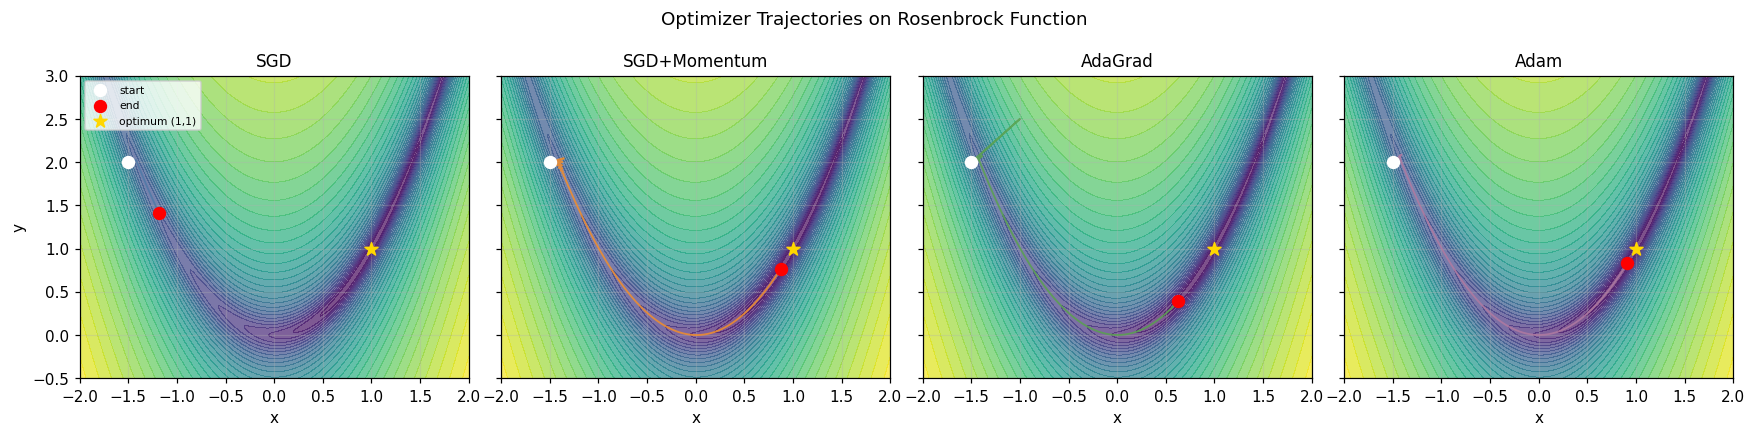

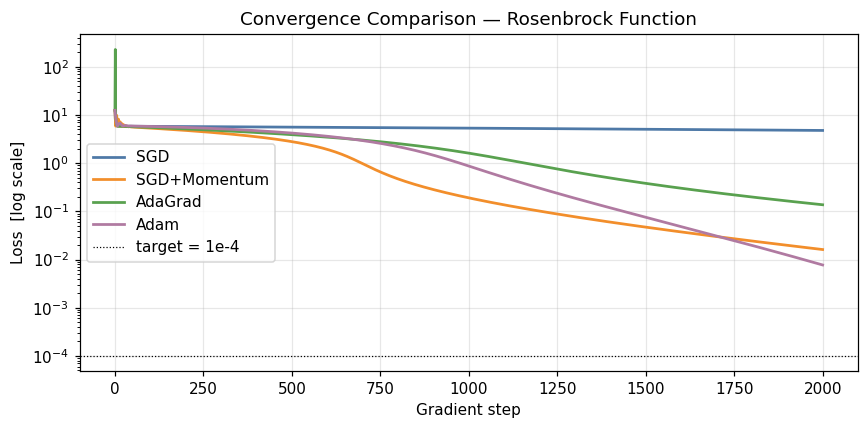

In [8]:
# Trajectory plot
x_grid = np.linspace(-2, 2, 300)
y_grid = np.linspace(-0.5, 3, 300)
X_g, Y_g = np.meshgrid(x_grid, y_grid)
Z_g = (1 - X_g)**2 + 100*(Y_g - X_g**2)**2

colors_map = {
    "SGD":          "#4e79a7",
    "SGD+Momentum": "#f28e2b",
    "AdaGrad":      "#59a14f",
    "Adam":         "#b07aa1",
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (name, r) in zip(axes, results.items()):
    ax.contourf(X_g, Y_g, np.log1p(Z_g), levels=30, cmap="viridis", alpha=0.7)
    path = r["path"]
    ax.plot(path[:, 0], path[:, 1], color=colors_map[name], lw=1.2, alpha=0.85)
    ax.scatter(path[0, 0],  path[0, 1],  color="white", s=60, zorder=5, label="start")
    ax.scatter(path[-1, 0], path[-1, 1], color="red",   s=60, zorder=5, label="end")
    ax.scatter(1, 1, color="gold", s=80, zorder=6, marker="*", label="optimum (1,1)")
    ax.set_title(name, fontsize=11); ax.set_xlabel("x")
    ax.set_xlim(-2, 2); ax.set_ylim(-0.5, 3)
axes[0].set_ylabel("y")
axes[0].legend(fontsize=7, loc="upper left")
plt.suptitle("Optimizer Trajectories on Rosenbrock Function", fontsize=12)
plt.tight_layout(); plt.show()

# Convergence curves
plt.figure(figsize=(8, 4))
for name, r in results.items():
    plt.semilogy(r["losses"], label=name, color=colors_map[name], lw=1.8)
plt.axhline(1e-4, color="k", lw=0.8, linestyle=":", label="target = 1e-4")
plt.xlabel("Gradient step"); plt.ylabel("Loss  [log scale]")
plt.title("Convergence Comparison — Rosenbrock Function")
plt.legend(); plt.tight_layout(); plt.show()

Interpretation:
  • SGD barely moves — lr=2e-4 is too small relative to Rosenbrock's curvature.
  • SGD+Momentum escapes the flat region faster and follows the valley more directly.
  • AdaGrad adapts per-parameter LRs: initially fast, but G_t grows without bound,
    causing the effective LR to shrink to near zero after ~500 steps.
  • Adam (AdaGrad + Momentum + bias correction) maintains a healthy effective LR
    throughout and converges closest to the true minimum (1, 1).